# Центральная предельная теорема. Закон больших чисел
---

**Закон больших чисел** доказывает интуитивно понятный факт, состоящий в том, что выборочное среднее будет стремиться к математическому ожиданию элементов выборки при объеме выборке, стремящемся к бесконечности (напоминаем, что элементы выборки являются независимыми случайными величинами с одинаковым распределением).  

**Центральная предельная теорема** расширяет этот результат и объясняет, что распределение выборочного среднего будет стремиться к знаменитому нормальному распределению при большом объеме выборке. 

## Закон больших чисел

**Формулировка**

Пусть $X_1, ..., X_n$ – попарно независимые случайные величины из некоторого распределения (*iid, identically independently distributed* – независимы и одинаково распределены), причем $M(X_i) = \mu$. Тогда выполнена сходимость $$\frac{X_1 + ... + X_n}{n} \stackrel{п.н.}{\longrightarrow} \mu.$$ 

*Замечание 1.* Закон больших чисел имеет несколько формулировок. Данная формулировка часто называется *усиленным законом больших чисел*. В частности, усиленной она является, поскольку в отличии от "простой" версии она не требует условия на дисперсии и утверждает о более сильной сходимости "почти наверное".

*Замечание 2.* Последовательность случайных величин $X_1, X_2, ...$ сходится ***почти наверное*** к случайной величине $X$, если $\mathsf{P}\big(\big\{ \omega \in \Omega\:\big|\: X_n(\omega) \to X(\omega)\big\}\big) = 1$

---

####  Визуализация

Убедимся в справедливости ЗБЧ, сгенерировав набор из случайных величин  $X_1, ..., X_{1000}$ и посчитав по нему среднее в зависимости от размера набора, то есть величины $S_{n} = \frac{1}{n}\sum\limits_{i=1}^n X_i$ для $1 \leqslant n \leqslant 1000$.

**Пример 1**. Для примера рассмотрим бернуллиевское распределение.

In [1]:
import numpy as np
import scipy.stats as sts
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=1.6, palette='summer')

In [2]:
size = 1000  # количество случайных величин

samples = sts.bernoulli(p=0.5).rvs(size=size)
cum_means = samples.cumsum() / (np.arange(size) + 1)

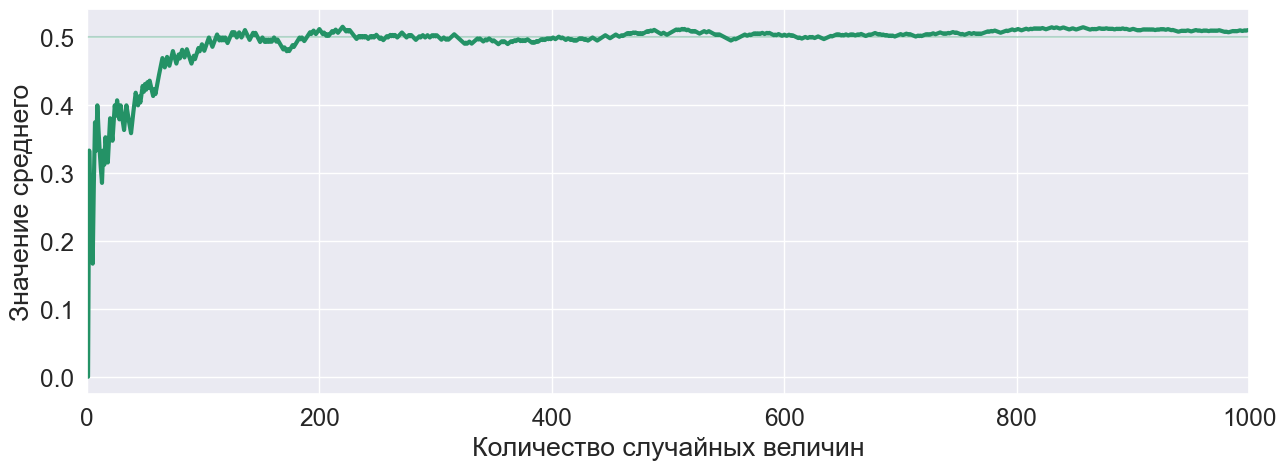

In [3]:
# Построим график
plt.figure(figsize=(15, 5))
plt.plot(cum_means, lw=3)
plt.hlines(0.5, 0, size, alpha=0.3)
plt.xlabel('Количество случайных величин')
plt.ylabel('Значение среднего')
plt.xlim((0, size));

Но одного эксперимента мало, чтобы понять свойства вероятностных объектов. **Запомните это!**

Повторим эксперимент $10$ раз независимо.

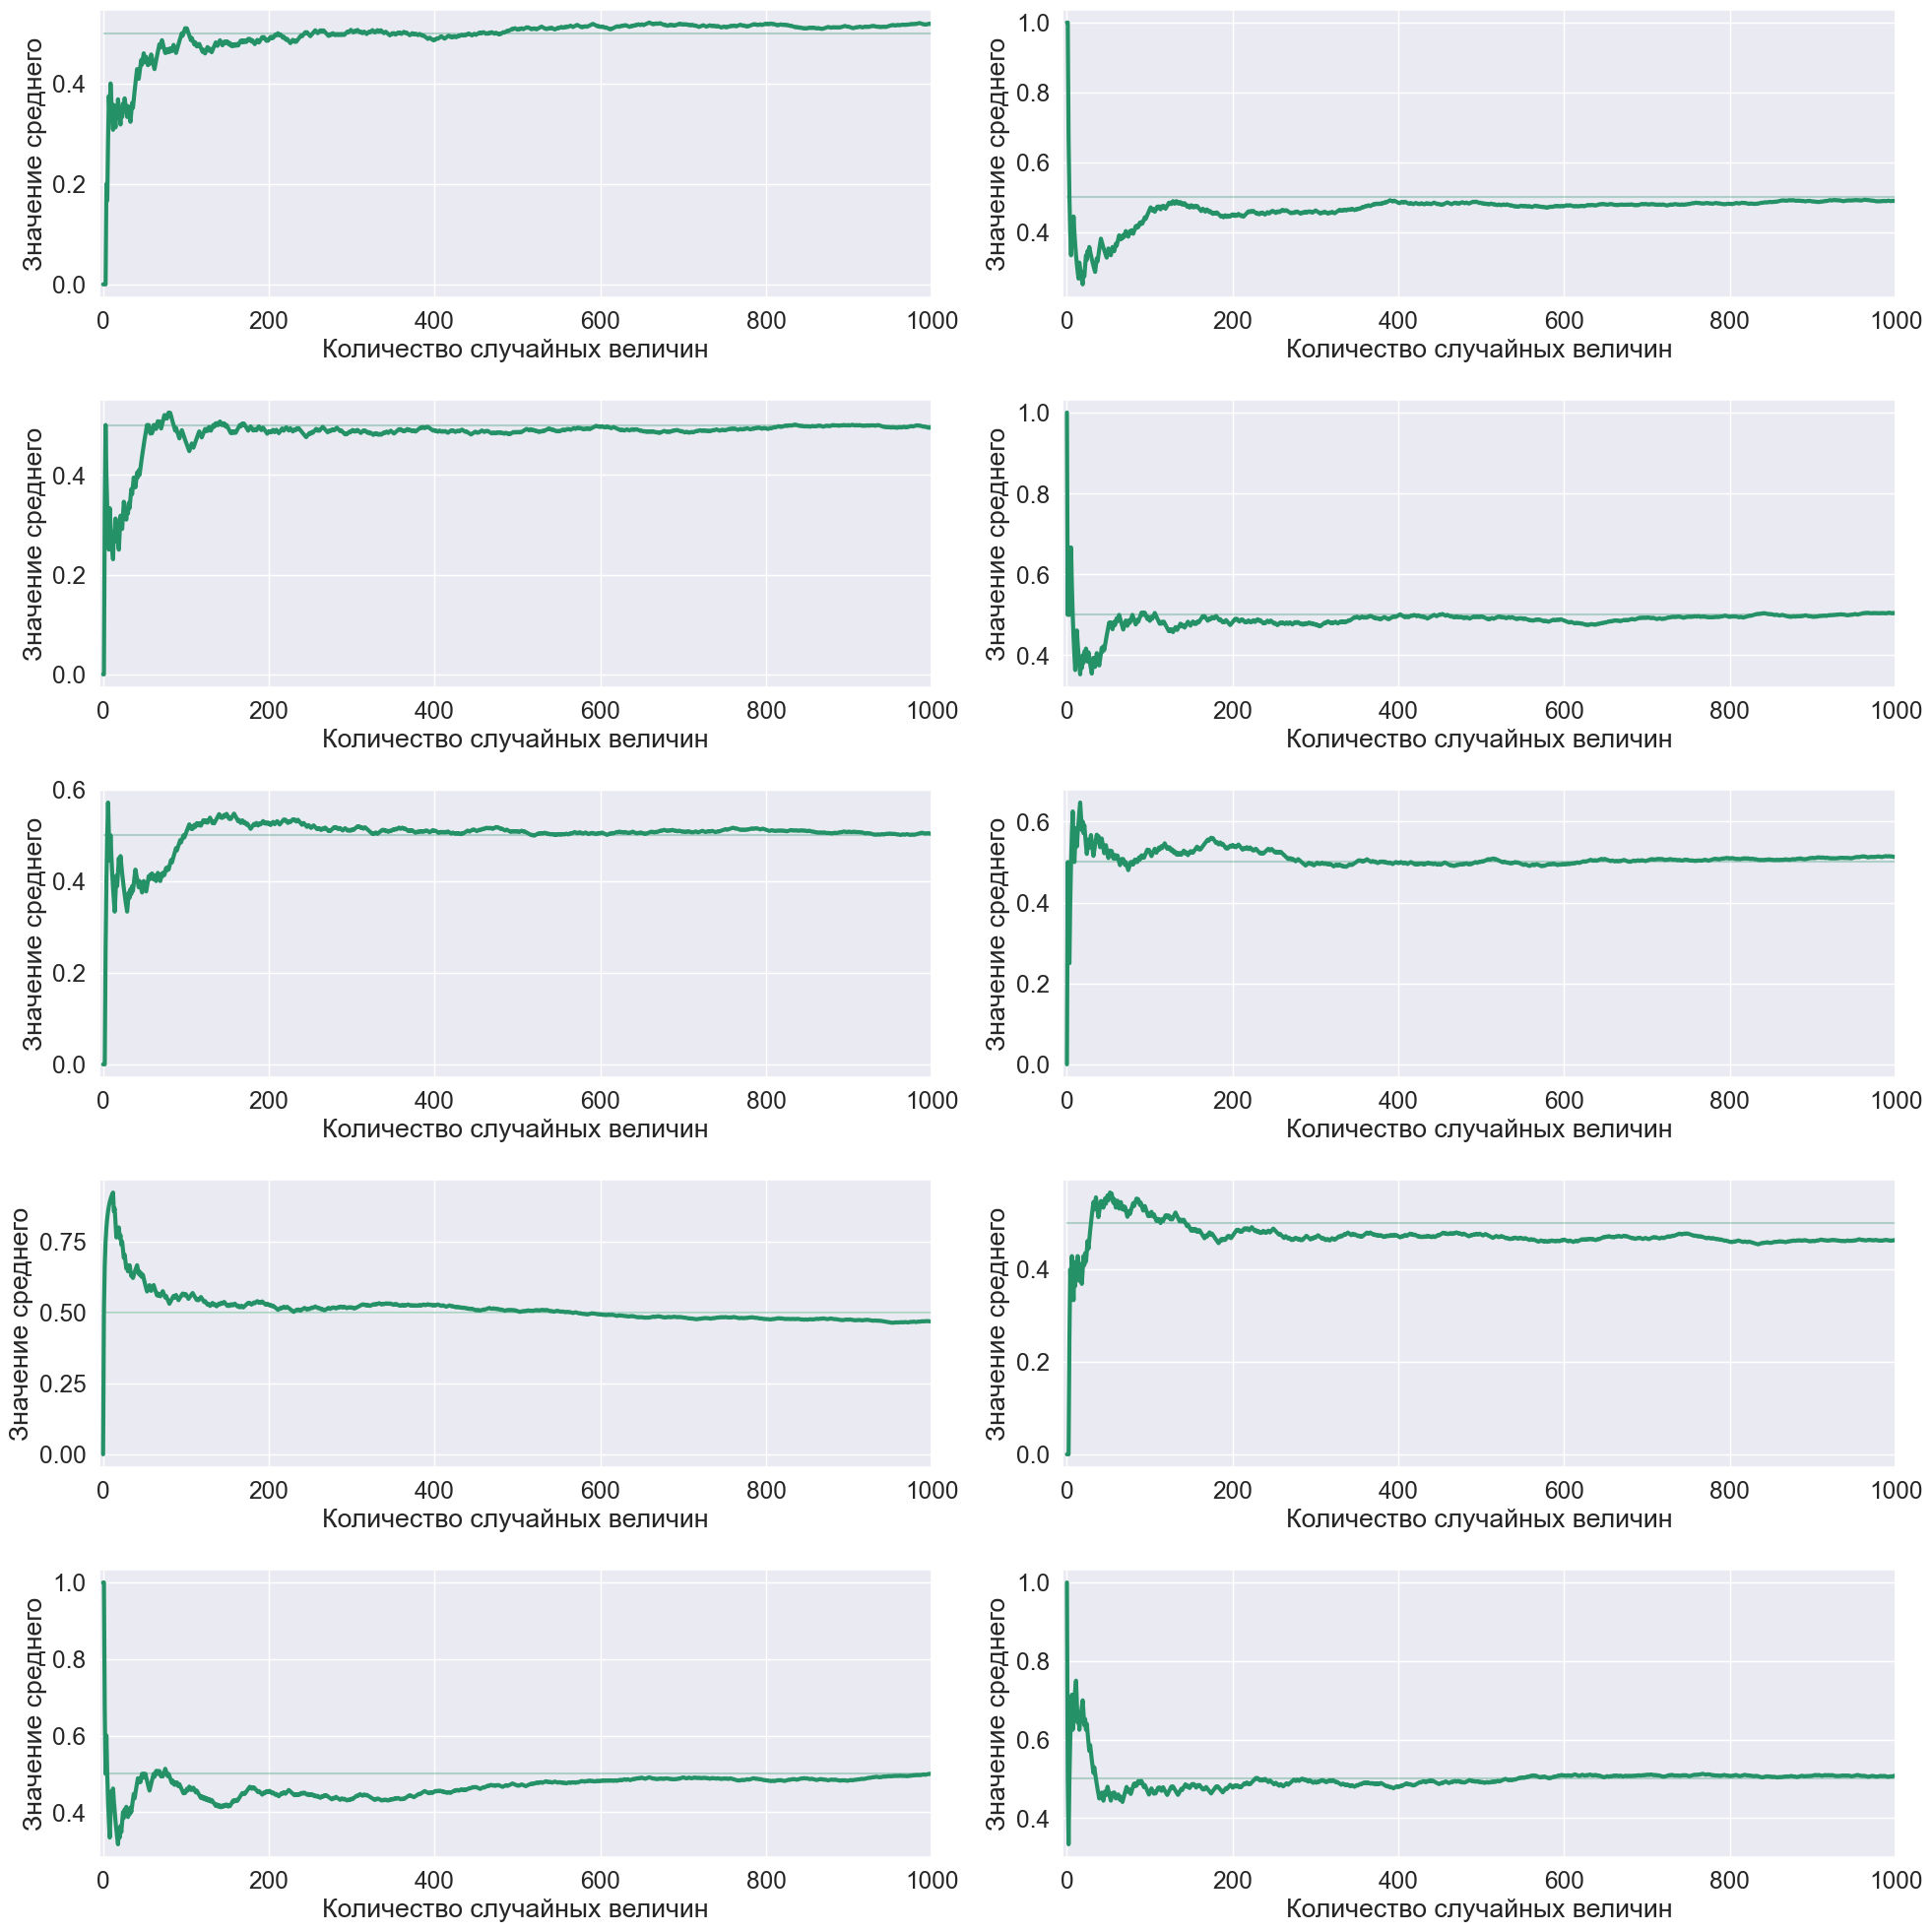

In [4]:
plt.figure(figsize=(20, 20))

# эксперименты
for i in range(10):

    # Генерация выборки и вычисление средних
    samples = sts.bernoulli(p=0.5).rvs(size=size)
    cum_means = samples.cumsum() / (np.arange(size) + 1)
    
    # График
    plt.subplot(5, 2, i+1)
    plt.plot(cum_means, lw=3)
    plt.hlines(0.5, 0, size, alpha=0.3)
    plt.xlabel('Количество случайных величин')
    plt.ylabel('Значение среднего')
    plt.xlim((-5, size))
    
plt.tight_layout()

Сгенерируем большое количество независимых наборов случайных величин для разных распределений.

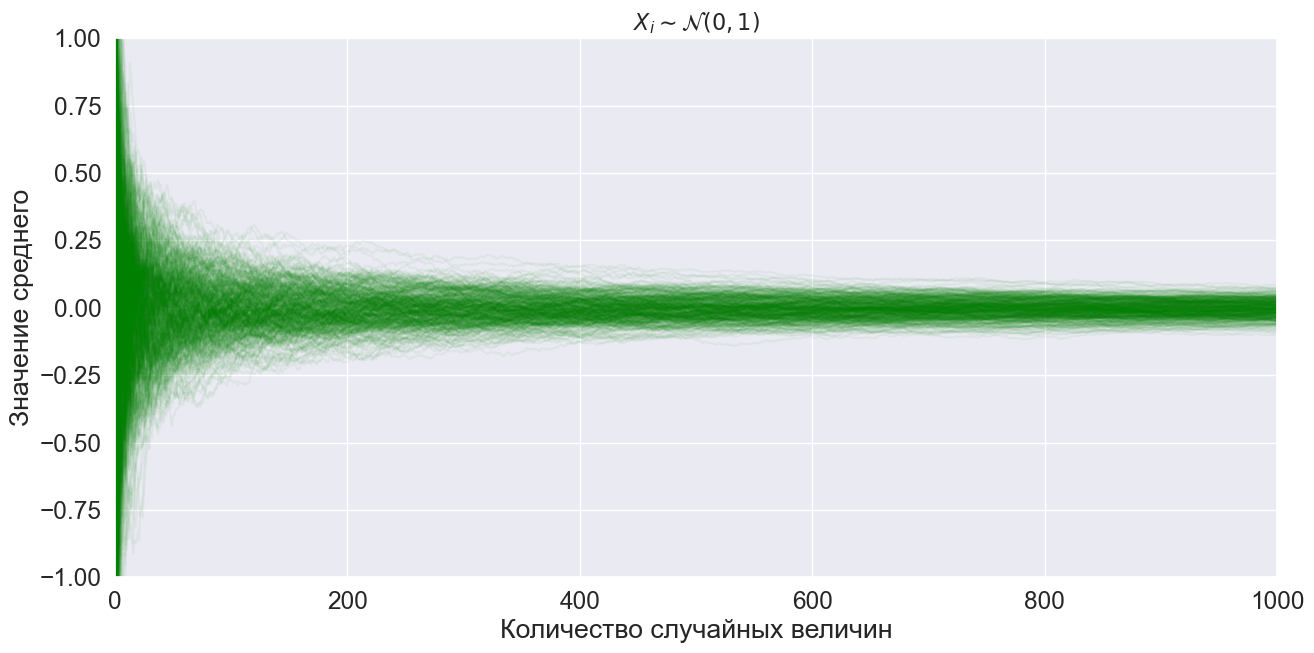

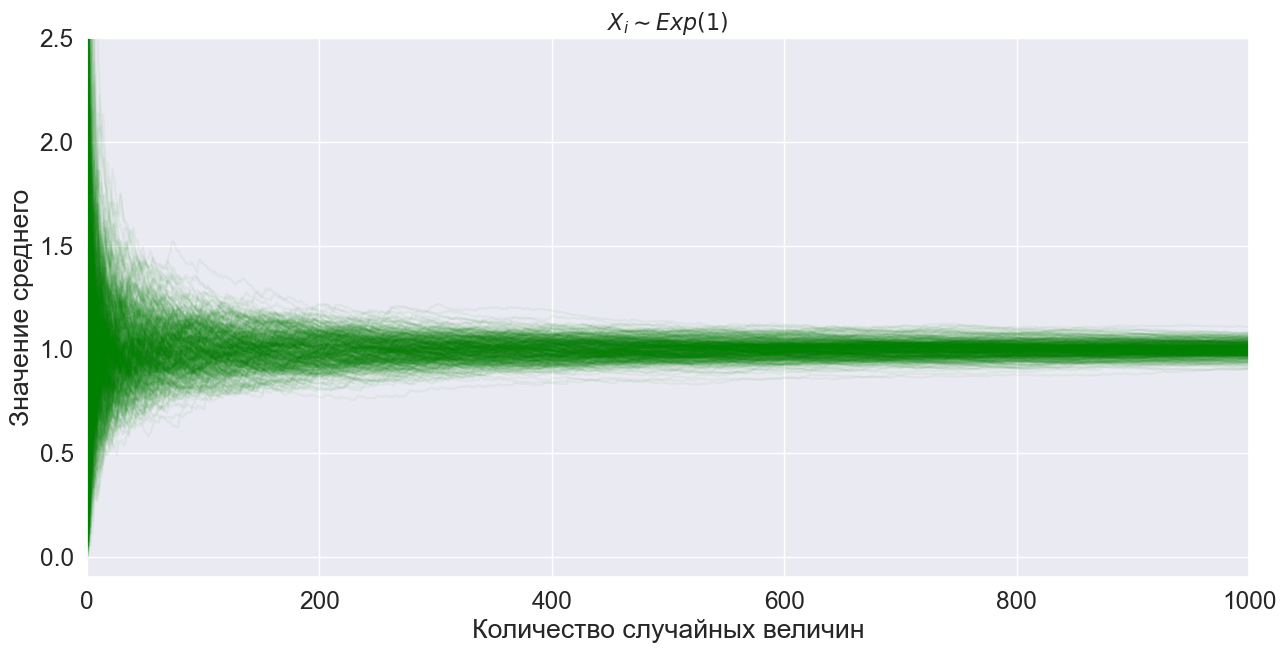

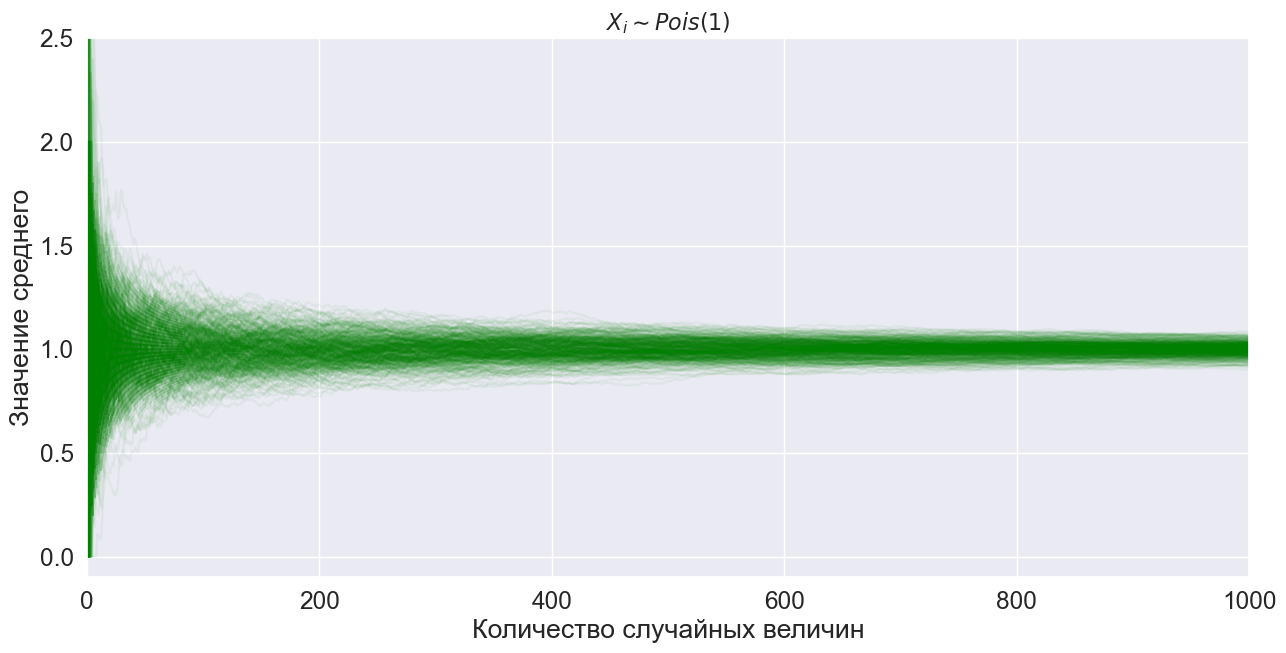

In [5]:
size = 1000
samples_count = 500

for distr, ylim, label in zip(
    [sts.norm(), sts.expon(), sts.poisson(mu=1)], 
    [(-1, 1), (-0.1, 2.5), (-0.1, 2.5)],
    ['$\\mathcal{N}(0, 1)$', '$Exp(1)$', '$Pois(1)$']
):
    
    # Генерация выборки и вычисление средних
    samples = distr.rvs(size=(samples_count, size))
    cum_means = samples.cumsum(axis=1) / (np.arange(size) + 1)

    # График
    plt.figure(figsize=(15, 7))
    for i in range(samples_count):
        plt.plot(np.arange(size) + 1, cum_means[i], color='green', alpha=0.05)
    plt.title('$X_i \\sim ' + label[1:], fontsize=16)
    plt.xlabel('Количество случайных величин')
    plt.ylabel('Значение среднего')
    plt.xlim((0, size));
    plt.ylim(ylim)
    plt.show()

**Вывод**: При достаточность большом количестве случайных величин значение среднего не сильно отклоняется от математического ожидания, причем чем больше случайных величин просуммированы, тем меньше отклонения. Данный эксперимент хорошо визуализирует закон больших чисел.

**Пример 2**. Мы знаем что математическое ожидание числа очков, выпавших на игральной кости это $3.5$. Сделаем симуляцию

* подкинем кость $1$ раз посчитаем среднее число на ней
* подкинем кость $2$ раза посчитаем среднее число на ней
* подкинем кость $100$ раз посчитаем среднее число на ней

Построим картинку для всех этик средних и убедимся в том что оно и правда сходится к $3.5$

In [10]:
size = 100  # количество подбрасываний

dice = np.random.choice(np.arange(1, 7), size=size)
cum_means = dice.cumsum() / (np.arange(size) + 1)

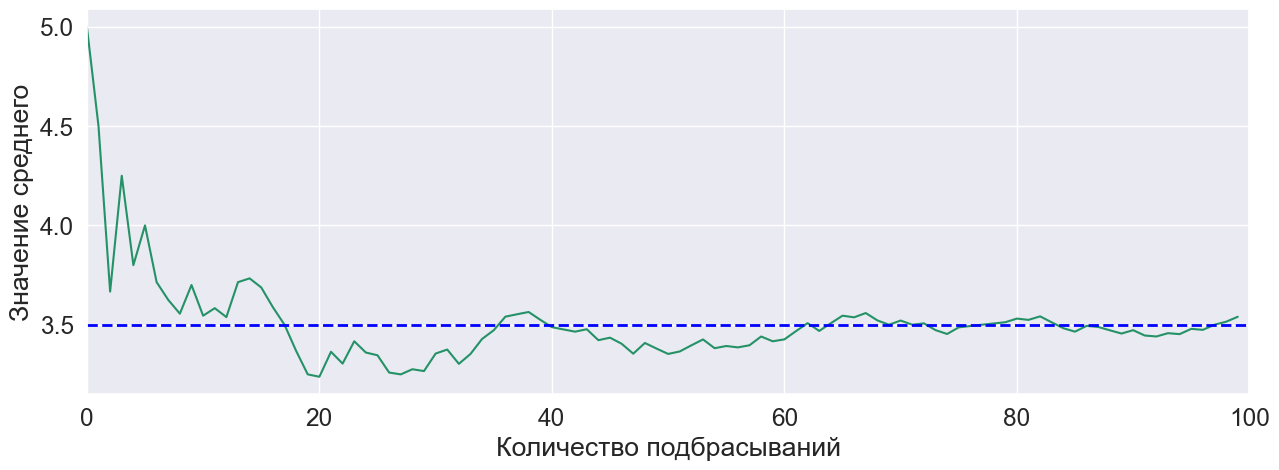

In [17]:
# Построим график
plt.figure(figsize=(15, 5))
plt.plot(cum_means)
plt.axhline(3.5, color='blue', linestyle='dashed', linewidth=2)
plt.xlabel('Количество подбрасываний')
plt.ylabel('Значение среднего')
plt.xlim((0, size));

## Сходимость по вероятности

Над стрелкой в ЗБЧ есть букв $P$:

$\frac{X_1 + ... + X_n}{n} \stackrel{P}{\longrightarrow} \mu$

Она означает, что последовательность случайных величин слева сходится к случайной величине справа по вероятности, то есть чем больше $n$ тем ближе вероятность отклонения $\bar{x}_n$ от $\mu$ к нулю.



Нарисуем её. Возьмем $\varepsilon = 0.01$. нарисуем на нашей предыдущей картинке коридор $3.5 ± \varepsilon$. продолжим ряд до $100000$ подбрасываний и увидим, как постепенно $\bar{x}_n$ попадает в коридор и всё реже выбивается из него.


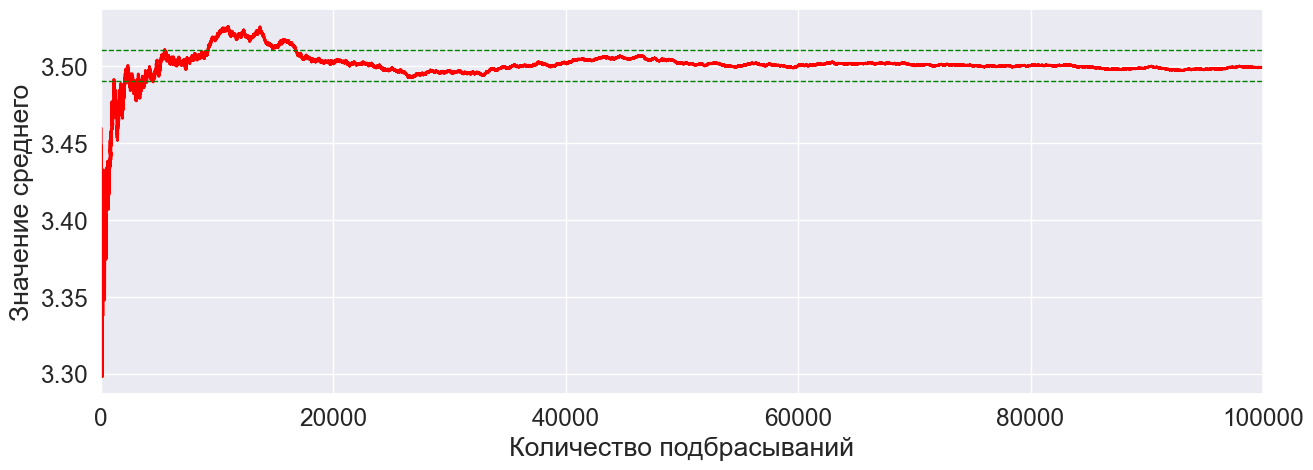

In [56]:
size = 100000  # количество подбрасываний
eps = 0.01

dice = np.random.choice(np.arange(1, 7), size=size)
cum_means = dice.cumsum() / (np.arange(size) + 1)

plt.figure(figsize=(15, 5))
plt.plot(cum_means[100:], color='red', linewidth=2)
plt.axhline(3.5 + eps, color='g', linestyle='dashed', linewidth=1)
plt.axhline(3.5 - eps, color='g', linestyle='dashed', linewidth=1)
plt.xlabel('Количество подбрасываний')
plt.ylabel('Значение среднего')
plt.xlim((0, size));

Выясним, как часто происходит выпадание случайной величины за пределы коридора. 

Можно попробовать оценить вероятность того, что последовательность из средних пробьет на конкретном шаге установленный нами коридор. Для этого давайте сгенерируем много-много траекторий для игральной кости, как на картинке выше. А после посмотрим как часто на конкретном шаге эти траектории пробивают коридор $3.5 ± \varepsilon$. Частота таких пробоин будет оценкой вероятности

$$P(\mid \bar{x}_n  - 3.5 \mid \geq \varepsilon)$$

In [57]:
size  = 10**4

# каждый раз подбрасыдаем кубик 2000 раз
dice = np.random.choice(np.arange(1, 7), size=(size, 1000))

# по строком считаем кумялятидную сумму
dice_cumsum = np.cumsum(dice, axis=0)

# находим средние
dice_mean = dice_cumsum / np.arange(1, size + 1)[:,None]
dice_mean.shape

(10000, 1000)

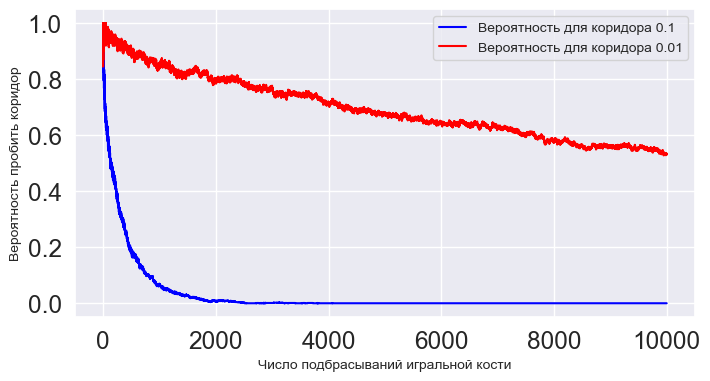

In [58]:
eps1 =  0.1
eps2 = 0.01

# все события, когда пробили коридор
bad_events_l = np.abs(dice_mean - 3.5) > eps1 
bad_events_2 = np.abs(dice_mean - 3.5) > eps2

# вероятноспъ пробоины
proba_l = np.mean(bad_events_l, axis=1) 
proba_2 = np.mean(bad_events_2, axis=1)

plt.figure(figsize=(8,4))
plt.plot(proba_l, color='blue', label=f"Вероятность для коридора {eps1}") 
plt.plot(proba_2, color='red', label = f"Вероятность для коридора {eps2}") 
plt.xlabel('Число подбрасываний игральной кости', fontsize=10) 
plt.ylabel('Вероятность пробить коридор', fontsize=10) 
plt.legend(fontsize=10);

Как мы видим вероятность пробить коридор поначалу является высокой, но постепенно убывает (синяя линия падает на порядок быстрее, нежели красная). При этом для более узкого коридора вероятность убывает медленнее что логично.

Сходимость по вероятности говорит о том,что какой бы мы коридор не зафиксировали, вероятность выйти за пределы коридора на бесконечности будет равна нулю. 

Для нашей ситуации со сходимостью к константе можно построить аналогичные графики для дисперсии среднего.

Немного позже мы ее вычислим. Окажется, что это

$$D(\bar{x}_n) = \frac {D(X_1 + X_2 + ... + X_n)} {n^2} = \frac {D(X_1)} {n}$$

В знаменателе у нас $n$. По мере роста выборки разброс убывает и среднее сходится к математическому ожиданию.

Важно держать в голове, что **дисперсия убывает только при сходимости к константе**!


**Важно**. При сходимости по вероятности: есть коридор, который может быть пробит. Он может быть пробит в любой момент: и при $10$ и при $100$ и при $1000$ наблюдений. Но вероятность пробоины с ростом числа наблюдений становится все меньше и меньше. И если это так, то последовательность сходится по вероятности.

## Расходимость по вероятности

Теперь мы знаем как выглядит сходимость по вероятности. Интересно было бы посмотреть как выглядит её отсутствие.

У стандартного распределения Коши такая плотность:

$$f_X(x) = \frac {1} {\pi (1 + x^2)}$$

Это распределение приносит кучу проблем. Одна из таких проблем - это отсутствие математического ожидания и дисперсии. Хотя распределение Коши и симметрично относительно нуля, но сходимости к нему нет.

ЗБЧ говорит нам, что для некоторых распределений

$$P(\mid \bar{x}  - M(X) \mid \geq \varepsilon) \rightarrow 0$$

то есть выборочное среднее по вероятности сходится к математическому ожиданию. Интересно было бы узнать к чему будет сходиться выборочное среднее для распределения Коши (математического ожидания то не существует).

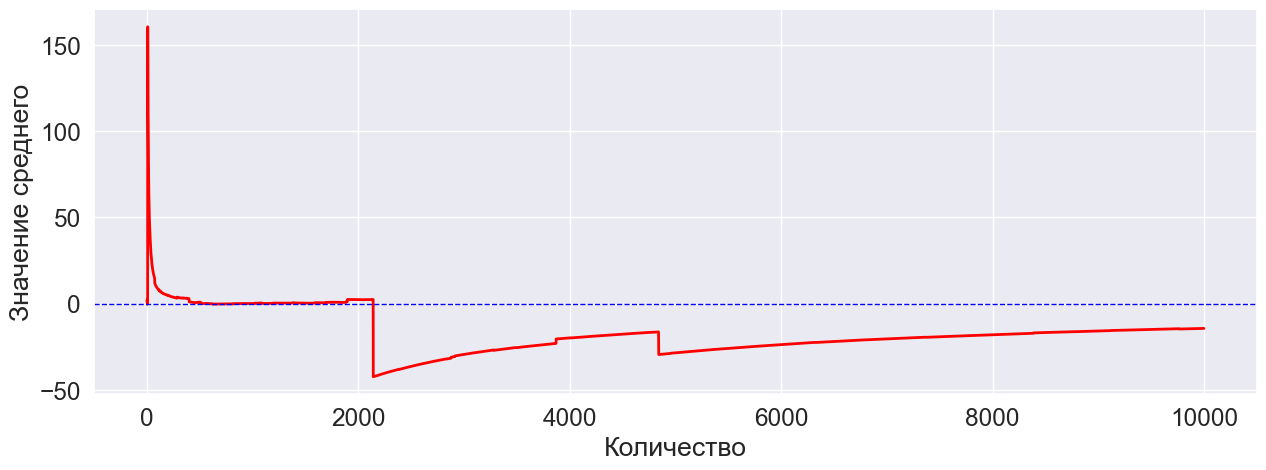

In [72]:
size  = 10**4

cauchu_rvs = sts.cauchy()
x = cauchu_rvs.rvs(size=(size, 1000))

# по строком считаем кумялятидную сумму
cauchu_cumsum = np.cumsum(x, axis=0)

# находим средние
cauchu_mean = cauchu_cumsum / np.arange(1, size + 1)[:,None]

plt.figure(figsize=(15, 5))
plt.plot(cauchu_mean[:, 700], color='red', linewidth=2)
plt.axhline(0, color='b', linestyle='dashed', linewidth=1)
plt.xlabel('Количество')
plt.ylabel('Значение среднего')
plt.show();

Посмотрим, что происходит с вероятностями?

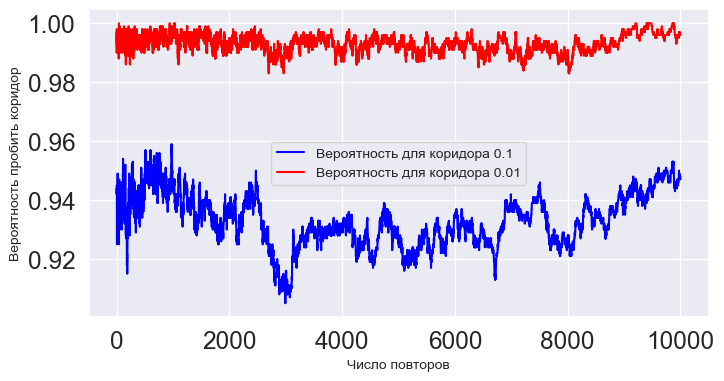

In [74]:
eps1 =  0.1
eps2 = 0.01

# все события, когда пробили коридор
bad_events_l = np.abs(cauchu_mean - 0) > eps1 
bad_events_2 = np.abs(cauchu_mean - 0) > eps2

# вероятноспъ пробоины
proba_l = np.mean(bad_events_l, axis=1) 
proba_2 = np.mean(bad_events_2, axis=1)

plt.figure(figsize=(8,4))
plt.plot(proba_l, color='blue', label=f"Вероятность для коридора {eps1}") 
plt.plot(proba_2, color='red', label = f"Вероятность для коридора {eps2}") 
plt.xlabel('Число повторов', fontsize=10) 
plt.ylabel('Вероятность пробить коридор', fontsize=10) 
plt.legend(fontsize=10);

**Вывод**. Видим, что вероятности не сходятся к нулю, они не стабилизируются около конкретно значения.  Постоянные пробоины в нашем коридоре. При этом во времени их количество никак не уменьшается Так выглядит отсутствие сходимости по вероятности. Обратите внимание, что величина пробоины не очень важна В случае, когда сходимость есть, пробоины также могут быть очень большими, но они происходят всё реже. 

## Центральная предельная теорема

**Формулировка**

Пусть $X_1, ..., X_n$ – попарно независимые случайные величины из некоторого распределения (*iid, identically independently distributed* – независимы и одинаково распределены), т.е. $X_1, ..., X_n \sim iid(\mu, \sigma^2)$, причем $M(X_i) = \mu$. Тогда при $n {\longrightarrow} \infty$  выполнена сходимость 

$\frac{X_1 + ... + X_n - \mu \cdot n}{\sqrt {n} \sigma} \stackrel{D} {\longrightarrow} N(0, 1)$

**Простым языком**:
* При определенных условиях сумма достаточно большого числа случайных величин имеет распределение близкое к нормальному
* Главное, чтобы случайные величины были похожи и не было такого, что одна резко выделяется на фоне остальных

###  ЦПТ для равномерного закона распределения

Пусть $X \sim U[-1; 1]$, тогда $\mu = \frac {1 + (-1)} {2} = 0, \sigma = \sqrt {\frac {(-1 - 1)^2} {12}} = 0.577$. Пусть  $Y = X_1 + ... + X_n$

* Нарисуем гистограмму для  $X_1$,  $X_1 + X_2$, $X_1 + X_2 + X_3$, $X_1 + X_2 + X_3 + X_4$.
* На последней картинке нарисуем плотность распределения $N(0, 1)$ и визуально сравним, насколько сильно оно отличается от гистограммы.

In [1]:
import numpy as np
import scipy.stats as sts
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [23]:
n_obs = 10**5
# обратите внимание, что в этой функции задается левая граница и длина
uniform_rvs = sts.uniform(-1, 2)
x_1 = uniform_rvs.rvs(n_obs)
x_2 = uniform_rvs.rvs(n_obs)
x_3 = uniform_rvs.rvs(n_obs)
x_4 = uniform_rvs.rvs(n_obs)

In [25]:
a, b = -1, 1
mu = (a + b) / 2
sigma = np.sqrt(((b - a) ** 2) / 12) 

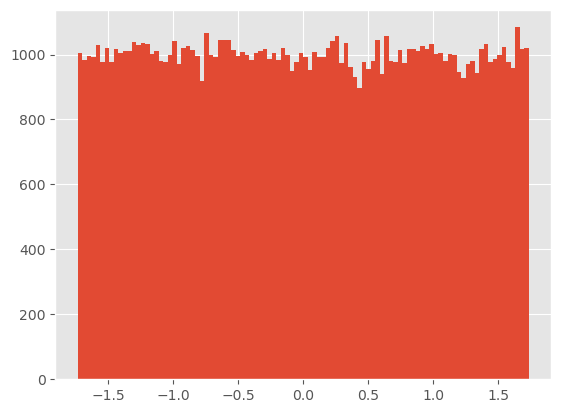

In [27]:
n = 1
plt.hist((x_1 - mu * n) / (np.sqrt(n) * sigma), bins=100);

Построим гистограмму для суммы $X_1 + X_2$. Увидим треугольник (распределение *Симпсона*).

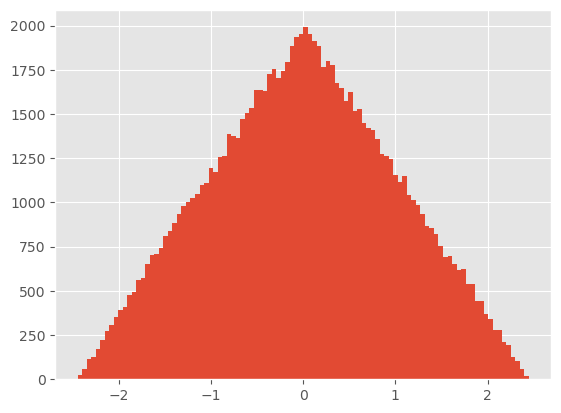

In [30]:
n = 2
plt.hist((x_1 + x_2 - mu * n) / (np.sqrt(n) * sigma), bins=100);

Построим гистограмму для суммы $X_1 + X_2 + X_3$. Уже увидим куполообразное распределение.

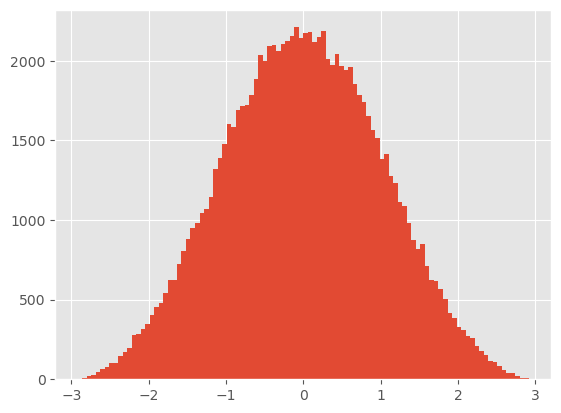

In [31]:
n = 3
plt.hist((x_1 + x_2 + x_3 - mu * n) / (np.sqrt(n) * sigma), bins=100);

Построим гистограмму для суммы $X_1 + X_2 + X_3 + X_4$. Еще выведем на картинку плотность распределения.

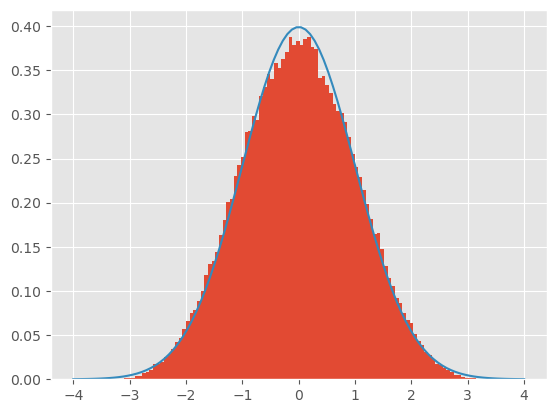

In [32]:
n = 4
plt.hist((x_1 + x_2 + x_3 + x_4 - mu * n) / (np.sqrt(n) * sigma), bins=100, density=True)

# пририсуем нормальное распределение
x = np.linspace(-4, 4, 100)
pdf = sts.norm().pdf(x)
plt.plot(x, pdf);

Если добавлять слагаемые в сумму, то наша красная гистограмма с ростом числа слагаемых станет неотличима от голубой плотности.

На практике ЦПТ говорит нам что при больших значениях $n$ мы можем заменять распределение средних нормальным и не особо сильно при этом ошибаться.

Возникает вопрос **А что таков большие значения $n$? Когда наступает асимптотика?** 

Для разных распределении и природных явлений она наступает по-разному: для одних сходимость к нормальному распределению идет быстрее, для других – медленнее. 

Из довольно медленно сходящихся к нормальному распределению, наверное, можно выделить логнормальное распределение.

Для равномерного уже для четырех слагаемых распределение довольно сильно напоминает $N(0, 1)$.


##  Сходимость по распределению

В ЦПТ над мы написали над стрелкой букву $D$. Она означает, что последовательность случайных величин сходится ***по распределению***.

> Говорят, что последовательность случайных величин  $X_1, ...$ сходится к случайной величине $X$ **по распределению**, если $F_{X_n}(x) {\longrightarrow} F_X(x)$ для всех $x$, в которых $F_X(x)$ непрерывна. Если функции сходятся, она есть. Если не сходятся, её нет.

**Пример**: распредеелние Стьюдента при большом $n$ (*число степеней свободы*) становится похоже на нормальное, то есть $t(x) \stackrel{D} {\longrightarrow} N(0, 1)$.

Давайте это продемонстрируем:
* Построим на картинке линию плотность для $N(0, 1)$.
* Построим пять пунктирных разноцветных линий: $t(1)$, $t(2)$, $t(5)$, $t(10)$, $t(50)$.
* Сделаем то же самое для функций распределения.

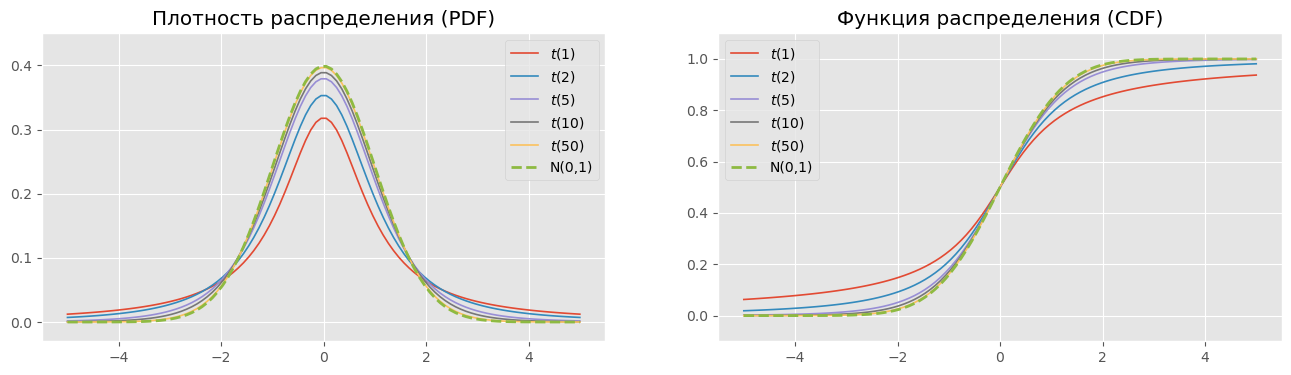

In [21]:
x = np.linspace(-5, 5, 100)

fig, ax = plt.subplots(1, 2, figsize=(16, 4))

for k in [1, 2, 5, 10, 50]:
    rvs = sts.t(df=k)
    pdf = rvs.pdf(x)
    cdf = rvs.cdf(x)
    ax[0].plot(x, pdf, label="$t(%s)$" % k, lw=1.2)
    ax[1].plot(x, cdf, label="$t(%s)$" % k, lw=1.2)

rvs_limit = sts.norm( )
pdf_limit = rvs_limit.pdf(x)
cdf_limit = rvs_limit.cdf(x)

ax[0].plot(x, pdf_limit, label='N(0,1)', linestyle='dashed', lw=2)
ax[0].set_ylim(-0.03, 0.45)
ax[0].set_title("Плотность распределения (PDF)")
ax[0].legend()

ax[1].set_ylim(-0.1, 1.1)
ax[1].plot(x, cdf_limit, label='N(0,1)', linestyle='dashed', lw=2)
ax[1].set_title("Функция распределения (CDF)")
ax[1].legend()

plt.show();

На картинке слева в идно, что к пунктирной зеленой линии, соответствующей нормальному распределению $N(0, 1)$, с увеличением $n$ (числа степеней свободы) постепенно приближается распределение Стьюдента. То же самое происходит с функцией распределения (графики справа).  